# Анализ результатов — полная абляция

Объединяет четыре источника (всё из `results/`):

| блок | источник | сиды |
|------|----------|------|
| Stage-1 single (EMO/AH) | `stage1_single_results.json` | — |
| Stage-2 fusion, без весов эмоций | `ablation_results.json` | 10 |
| Stage-2 fusion, с весами эмоций | `ablation_results_emo_w.json` | 5 |
| Attention-ablation (softmax/zeros/mhla/elsa) | `attention_ablation_results.json` | 1 (seed 42) |

Разделы: 1) stage-1 vs stage-2 · 2) эффект весов эмоций · 3) attention-ablation ·
4) мастер-таблица абляции · 5) графики `utils/plotting.py` → `plots/` · 6) выводы.

In [1]:
%matplotlib inline
import json, os, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

def find_pkg():
    for base in [Path.cwd(), Path.cwd().parent, *Path.cwd().parents]:
        if (base / "results" / "ablation_results.json").exists():
            return base
    return Path("/Users/ildarkhamaganov/Documents/HSE/NIR/mehr")
PKG = find_pkg(); RES = PKG / "results"
VENV = PKG.parent / ".venv" / "bin" / "python"   # для plotting (matplotlib+mlflow)

def load(name): return json.load(open(RES / name))
SINGLE = load("stage1_single_results.json")
NOW    = load("ablation_results.json")            # без весов, 10 сидов
EMOW   = load("ablation_results_emo_w.json")      # с весами, 5 сидов
ATTN   = load("attention_ablation_results.json")  # seed 42

# Сиды: без весов [42,0,123,1,2,7,13,21,100,2024]; emo_w — первые 5 → пара по позиции
SEEDS_NOW = [42, 0, 123, 1, 2, 7, 13, 21, 100, 2024]
COMMON_N  = 5   # общие сиды [42,0,123,1,2] для парного сравнения весов
EMO7 = ["Neutral","Anger","Disgust","Fear","Happiness","Sadness","Surprise"]
print("PKG:", PKG)
print("venv для plotting:", VENV, "—", "OK" if VENV.exists() else "НЕ НАЙДЕН")
print("эксперименты без весов:", list(NOW))
print("эксперименты с весами :", list(EMOW))
print("attention            :", sorted(set(k.rsplit('_',1)[-1] for k in ATTN)))

PKG: /Users/ildarkhamaganov/Documents/HSE/NIR/mehr
venv для plotting: /Users/ildarkhamaganov/Documents/HSE/NIR/.venv/bin/python — OK
эксперименты без весов: ['E3_fusion_no_ssl', 'E4_fusion_ssl', 'E5_fusion_gradnorm', 'E6_fusion_ssl_unfreeze']
эксперименты с весами : ['E3_fusion_no_ssl_emo_w', 'E4_fusion_ssl_emo_w', 'E5_fusion_gradnorm_emo_w', 'E6_fusion_ssl_unfreeze_emo_w']
attention            : ['elsa', 'mhla', 'softmax', 'zeros']


## 1. Stage-1 single vs Stage-2 fusion (без весов)

Даёт ли cross-domain fusion прирост над одиночными stage-1 энкодерами?

In [2]:
def ms(arr): a=np.array(arr); return a.mean(), a.std()

rows = []
rows.append({"модель":"Stage-1 EMO (single)", "тип":"stage-1",
             "emo_mf1":SINGLE["E2_emotion_stage1"]["emo_mf1"],
             "emo_uar":SINGLE["E2_emotion_stage1"]["emo_uar"],
             "ah_mf1":np.nan, "overall_f1":np.nan})
rows.append({"модель":"Stage-1 AH (single)", "тип":"stage-1",
             "emo_mf1":np.nan, "emo_uar":np.nan,
             "ah_mf1":SINGLE["E1_ah_stage1"]["ah_mf1"],
             "overall_f1":np.nan})
for e in NOW:
    rows.append({"модель":e, "тип":"stage-2 (no-w)",
                 "emo_mf1":ms(NOW[e]["emo_mf1"])[0], "emo_uar":ms(NOW[e]["emo_uar"])[0],
                 "ah_mf1":ms(NOW[e]["ah_mf1"])[0], "overall_f1":ms(NOW[e]["overall_f1"])[0]})
t1 = pd.DataFrame(rows).set_index("модель").round(4)
display(t1)

# наглядно: одиночные vs лучший fusion
best = max(NOW, key=lambda e: ms(NOW[e]["overall_f1"])[0])
print(f"Stage-1 EMO mf1={SINGLE['E2_emotion_stage1']['emo_mf1']:.4f} | "
      f"лучший fusion {best} emo_mf1={ms(NOW[best]['emo_mf1'])[0]:.4f} "
      f"(Δ={ms(NOW[best]['emo_mf1'])[0]-SINGLE['E2_emotion_stage1']['emo_mf1']:+.4f})")
print(f"Stage-1 AH  mf1={SINGLE['E1_ah_stage1']['ah_mf1']:.4f} | "
      f"лучший fusion {best} ah_mf1={ms(NOW[best]['ah_mf1'])[0]:.4f} "
      f"(Δ={ms(NOW[best]['ah_mf1'])[0]-SINGLE['E1_ah_stage1']['ah_mf1']:+.4f})")

,тип,emo_mf1,emo_uar,ah_mf1,overall_f1
модель,,,,,
Stage-1 EMO (single),stage-1,0.5848,0.6441,NaN,NaN
Stage-1 AH (single),stage-1,NaN,NaN,0.6853,NaN
E3_fusion_no_ssl,stage-2 (no-w),0.5840,0.5853,0.6756,0.6298
E4_fusion_ssl,stage-2 (no-w),0.5832,0.5847,0.6661,0.6247
E5_fusion_gradnorm,stage-2 (no-w),0.5824,0.5828,0.6602,0.6213
E6_fusion_ssl_unfreeze,stage-2 (no-w),0.5807,0.5817,0.6679,0.6243


Stage-1 EMO mf1=0.5848 | лучший fusion E3_fusion_no_ssl emo_mf1=0.5840 (Δ=-0.0009)
Stage-1 AH  mf1=0.6853 | лучший fusion E3_fusion_no_ssl ah_mf1=0.6756 (Δ=-0.0097)


## 2. Эффект весов эмоций (без весов → с весами)

Парно по общим сидам `[42, 0, 123, 1, 2]` (n=5). Δ = (с весами) − (без весов).
Ожидание из ранее проведённого разбора: веса поднимают **recall на редких классах**
(emo_uar / emo_mwacc), почти не трогая emo_mf1 (precision компенсирует).

In [3]:
def paired(a, b, n_boot=10000, seed=0):
    a=np.array(a,float); b=np.array(b,float); d=b-a
    rng=np.random.default_rng(seed)
    boot=d[rng.integers(0,len(d),(n_boot,len(d)))].mean(1)
    ci=(np.percentile(boot,2.5),np.percentile(boot,97.5))
    sd=d.std(ddof=1); dz=d.mean()/sd if sd>0 else 0.0
    try: w=stats.wilcoxon(a,b).pvalue
    except ValueError: w=np.nan
    return d.mean(), ci, w, dz

PAIRS = [("E3_fusion_no_ssl","E3_fusion_no_ssl_emo_w"),
         ("E4_fusion_ssl","E4_fusion_ssl_emo_w"),
         ("E5_fusion_gradnorm","E5_fusion_gradnorm_emo_w"),
         ("E6_fusion_ssl_unfreeze","E6_fusion_ssl_unfreeze_emo_w")]
METR = ["emo_mf1","emo_uar","emo_mwacc","ah_mf1","ah_wf1","overall_f1"]
rows=[]
for base, ew in PAIRS:
    for m in METR:
        a = NOW[base][m][:COMMON_N]       # первые 5 сидов = [42,0,123,1,2]
        b = EMOW[ew][m][:COMMON_N]
        dmean, ci, w, dz = paired(a, b)
        rows.append({"эксперимент":base.split("_")[0], "метрика":m,
                     "без весов":round(np.mean(a),4), "с весами":round(np.mean(b),4),
                     "Δ":round(dmean,4), "95% CI":f"[{ci[0]:+.4f},{ci[1]:+.4f}]",
                     "d_z":round(dz,2)})
weff = pd.DataFrame(rows)
display(weff)

,эксперимент,метрика,без весов,с весами,Δ,95% CI,d_z
0,E3,emo_mf1,0.5840,0.5972,0.0132,"[+0.0071,+0.0183]",1.86
1,E3,emo_uar,0.5855,0.6232,0.0377,"[+0.0313,+0.0449]",4.12
2,E3,emo_mwacc,0.5855,0.6232,0.0377,"[+0.0313,+0.0449]",4.12
3,E3,ah_mf1,0.6753,0.6692,-0.0061,"[-0.0214,+0.0101]",-0.30
4,E3,ah_wf1,0.6826,0.6805,-0.0021,"[-0.0176,+0.0138]",-0.10
5,E3,overall_f1,0.6297,0.6332,0.0036,"[-0.0055,+0.0137]",0.28
6,E4,emo_mf1,0.5842,0.5991,0.0149,"[+0.0095,+0.0200]",2.18
7,E4,emo_uar,0.5858,0.6279,0.0421,"[+0.0373,+0.0469]",7.08
8,E4,emo_mwacc,0.5858,0.6279,0.0421,"[+0.0373,+0.0469]",7.08
9,E4,ah_mf1,0.6615,0.6758,0.0143,"[+0.0018,+0.0333]",0.67


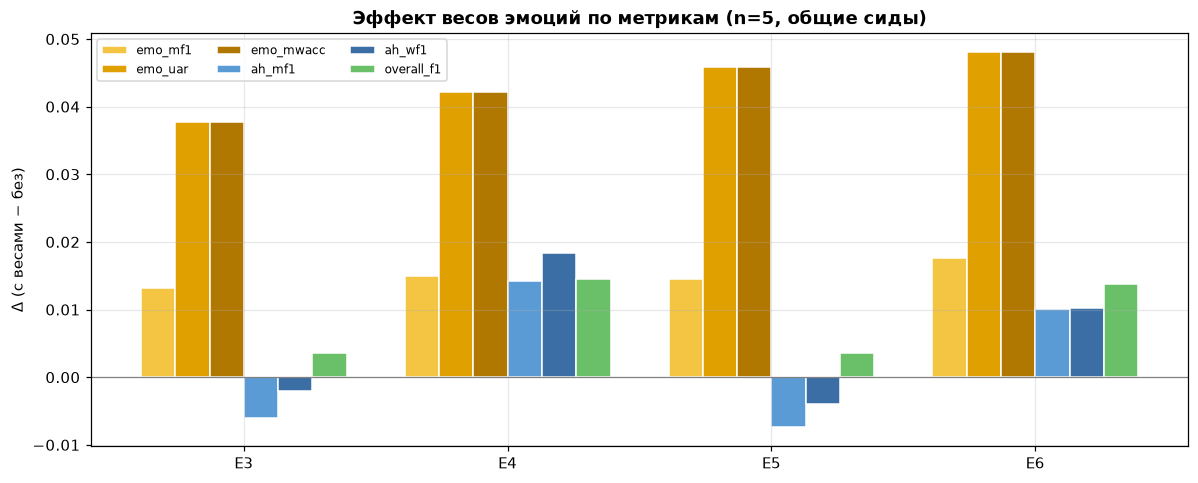

Замечание: n=5 → ориентир на знак Δ и CI, не на p-value.


In [4]:
# Бар-чарт Δ (с весами − без) по метрикам и экспериментам
fig, ax = plt.subplots(figsize=(11,4.5))
exps=[p[0].split("_")[0] for p in PAIRS]
x=np.arange(len(exps)); w=0.13
colors={"emo_mf1":"#f4c542","emo_uar":"#e0a000","emo_mwacc":"#b07800",
        "ah_mf1":"#5b9bd5","ah_wf1":"#3a6ea5","overall_f1":"#6abf69"}
for i,m in enumerate(METR):
    deltas=[paired(NOW[b][m][:COMMON_N], EMOW[e][m][:COMMON_N])[0] for b,e in PAIRS]
    ax.bar(x+(i-2.5)*w, deltas, w, label=m, color=colors[m], edgecolor="white")
ax.axhline(0,color="gray",lw=0.8); ax.set_xticks(x); ax.set_xticklabels(exps)
ax.set_ylabel("Δ (с весами − без)"); ax.legend(ncol=3, fontsize=8)
ax.set_title("Эффект весов эмоций по метрикам (n=5, общие сиды)", fontweight="bold")
plt.tight_layout(); plt.show()
print("Замечание: n=5 → ориентир на знак Δ и CI, не на p-value.")

## 3. Attention-ablation (softmax / zeros / mhla / elsa)

Stage-1 энкодеры с разными механизмами внимания из статей (seed 42) + сквозной
`fusion_grad_norm` поверх них. Δ — относительно softmax (like-for-like).

In [5]:
ATTNS=["softmax","zeros","mhla","elsa"]
def attn_table(task, metrics, primary):
    rows=[]; base=None
    for a in ATTNS:
        r=ATTN.get(f"{task}_{a}",{})
        row={"attn":a}
        for m in metrics: row[m]=round(r[m][0],4) if r.get(m) else np.nan
        if base is None: base=row[primary]
        row[f"Δ{primary}"]=round(row[primary]-base,4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("attn")

print("— stage-1 EMOTION —");           display(attn_table("emotion",["mf1","uar","mwacc"],"mf1"))
print("— stage-1 AH —");                display(attn_table("ah",["mf1","uar","wf1"],"mf1"))
print("— fusion_grad_norm (сквозной) —")
display(attn_table("fusion_grad_norm",["emo_mf1","ah_mf1","overall_f1"],"overall_f1"))

— stage-1 EMOTION —


,mf1,uar,mwacc,Δmf1
attn,,,,
softmax,0.5952,0.6209,0.6209,0.0000
zeros,0.6028,0.6278,0.6278,0.0076
mhla,0.5974,0.6370,0.6370,0.0022
elsa,0.5952,0.6209,0.6209,0.0000


— stage-1 AH —


,mf1,uar,wf1,Δmf1
attn,,,,
softmax,0.6655,0.6629,0.6837,0.0000
zeros,0.6698,0.6771,0.6795,0.0043
mhla,0.6652,0.6740,0.6741,-0.0003
elsa,0.6655,0.6629,0.6837,0.0000


— fusion_grad_norm (сквозной) —


,emo_mf1,ah_mf1,overall_f1,Δoverall_f1
attn,,,,
softmax,0.6060,0.6814,0.6437,0.0000
zeros,0.6055,0.6649,0.6352,-0.0085
mhla,0.6009,0.6523,0.6266,-0.0171
elsa,0.6060,0.6814,0.6437,0.0000


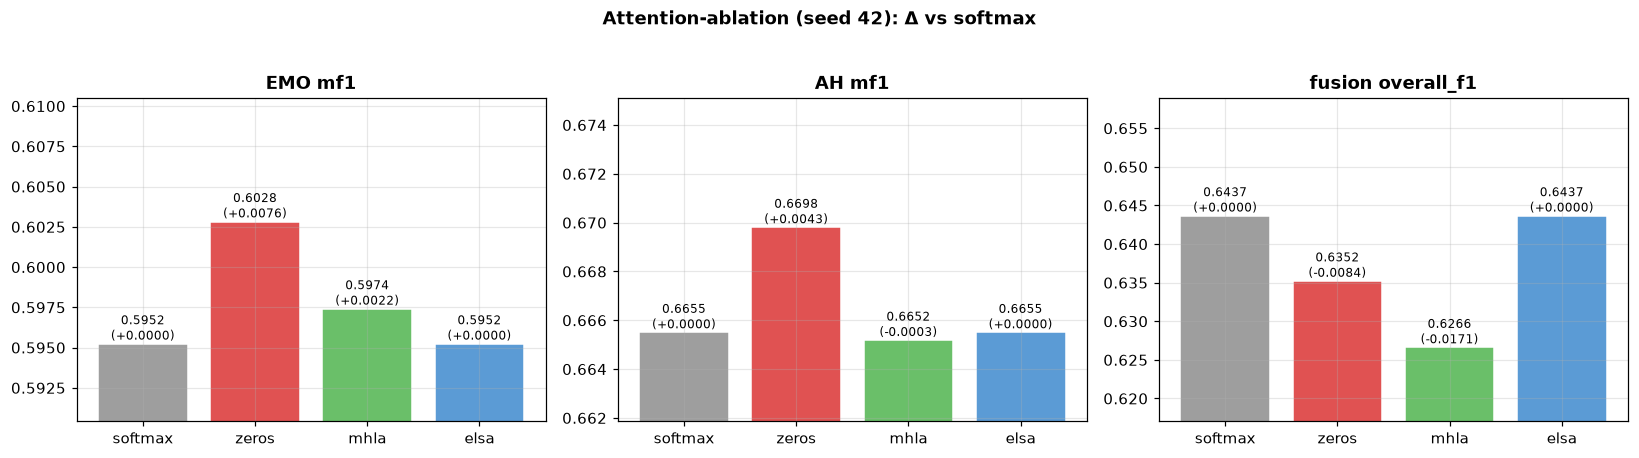

In [6]:
# Бар-чарты: первичная метрика по attn для трёх задач
fig, axes = plt.subplots(1,3, figsize=(15,4))
spec=[("emotion","mf1","EMO mf1"),("ah","mf1","AH mf1"),
      ("fusion_grad_norm","overall_f1","fusion overall_f1")]
for ax,(task,m,title) in zip(axes,spec):
    vals=[ATTN[f"{task}_{a}"][m][0] for a in ATTNS]
    bars=ax.bar(ATTNS, vals, color=["#9e9e9e","#e05252","#6abf69","#5b9bd5"], edgecolor="white")
    base=vals[0]
    for xi,v in enumerate(vals):
        ax.text(xi,v,f"{v:.4f}\n({v-base:+.4f})",ha="center",va="bottom",fontsize=8)
    ax.set_title(title, fontweight="bold")
    lo,hi=min(vals),max(vals); pad=(hi-lo)*0.5+1e-3; ax.set_ylim(lo-pad,hi+pad*1.6)
plt.suptitle("Attention-ablation (seed 42): Δ vs softmax", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

## 4. Мастер-таблица абляции

Всё в одной таблице: stage-1 single, stage-2 (±веса), attention-fusion. Для
многосидовых — mean; колонка `n` = число сидов.

In [7]:
def row_full(name, group, d, n):
    return {"группа":group, "модель":name, "n":n,
            "emo_mf1":d.get("emo_mf1"), "emo_uar":d.get("emo_uar"),
            "emo_mwacc":d.get("emo_mwacc"), "ah_mf1":d.get("ah_mf1"),
            "ah_uar":d.get("ah_uar"), "ah_wf1":d.get("ah_wf1"),
            "overall_f1":d.get("overall_f1")}

rows=[]
rows.append(row_full("Stage-1 EMO (single)","stage-1", SINGLE["E2_emotion_stage1"], 1))
rows.append(row_full("Stage-1 AH (single)","stage-1", SINGLE["E1_ah_stage1"], 1))
for e in NOW:
    d={m:ms(NOW[e][m])[0] for m in NOW[e]}; rows.append(row_full(e,"fusion no-w", d, len(NOW[e]["overall_f1"])))
for e in EMOW:
    d={m:ms(EMOW[e][m])[0] for m in EMOW[e]}; rows.append(row_full(e.replace("_emo_w"," +w"),"fusion +w", d, len(EMOW[e]["overall_f1"])))
for a in ATTNS:
    d={m:ATTN[f"fusion_grad_norm_{a}"][m][0] for m in ATTN[f"fusion_grad_norm_{a}"]}
    rows.append(row_full(f"attn-fusion {a}","attn-fusion", d, 1))

master = pd.DataFrame(rows).set_index(["группа","модель"]).round(4)
(PKG / "plots").mkdir(exist_ok=True)
master.to_csv(PKG / "plots" / "master_ablation_table.csv")
display(master)
print("CSV сохранён → plots/master_ablation_table.csv")

n  emo_mf1  emo_uar  emo_mwacc  ah_mf1  ah_uar  ah_wf1  overall_f1
группа      модель                                                                                        
stage-1     Stage-1 EMO (single)        1   0.5848   0.6441     0.6441     NaN     NaN     NaN         NaN
            Stage-1 AH (single)         1      NaN      NaN        NaN  0.6853  0.6868  0.6982         NaN
fusion no-w E3_fusion_no_ssl           10   0.5840   0.5853     0.5853  0.6756  0.6873  0.6831      0.6298
            E4_fusion_ssl              10   0.5832   0.5847     0.5847  0.6661  0.6813  0.6721      0.6247
            E5_fusion_gradnorm         10   0.5824   0.5828     0.5828  0.6602  0.6767  0.6657      0.6213
            E6_fusion_ssl_unfreeze     10   0.5807   0.5817     0.5817  0.6679  0.6808  0.6750      0.6243
fusion +w   E3_fusion_no_ssl +w         5   0.5972   0.6232     0.6232  0.6692  0.6742  0.6805      0.6332
            E4_fusion_ssl +w            5   0.5991   0.6279     0.6279  0.6758  0.6827  0.6857      0.6374
            E5_fusion_gradnorm +w       5   0.5969   0.6286     0.6286  0.6574  0.6685  0.6674      0.6271
            E6_fusion_ssl_unfreeze +w   5   0.5984   0.6296     0.6296  0.6760  0.6853  0.6847      0.6372
attn-fusion attn-fusion softmax         1   0.6060   0.6237     0.6237  0.6814  0.6864  0.6921      0.6437
            attn-fusion zeros           1   0.6055   0.6278     0.6278  0.6649  0.6767  0.6723      0.6352
            attn-fusion mhla            1   0.6009   0.6338     0.6338  0.6523  0.6657  0.6591      0.6266
            attn-fusion elsa            1   0.6060   0.6237     0.6237  0.6814  0.6864  0.6921      0.6437

CSV сохранён → plots/master_ablation_table.csv


In [13]:
master = master.drop(index="attn-fusion", level=0)

cols = [c for c in master.columns if c != "n"]

def rank_style(col):
    result = [""] * len(col)
    valid = col.dropna()
    if len(valid) == 0:
        return result

    best = valid.idxmax()
    result[col.index.get_loc(best)] = "font-weight:bold;"
    if len(valid) > 1:
        second = valid.drop(best).idxmax()
        result[col.index.get_loc(second)] = "text-decoration:underline;"
    return result

master.to_csv(PKG / "plots" / "master_ablation_table_best_selected.csv")
master.style.apply(rank_style, subset=cols, axis=0)

## 5. Графики `utils/plotting.py` → `plots/`

Для каждого эксперимента вызываем `utils/plotting.py` (через venv-python: matplotlib
+ mlflow) и складываем PNG в общую папку `plots/`. Stage-2 — из history JSON;
stage-1 — из MLflow run_name.

In [8]:
PLOTS = PKG / "plots"; PLOTS.mkdir(exist_ok=True)
env = dict(os.environ); env["PLOTS_DIR"] = str(PLOTS)

# (label, kind, arg). kind="json" → history-файл; kind="run" → MLflow run_name
jobs = []
for e in ["E3_fusion_no_ssl","E4_fusion_ssl","E5_fusion_gradnorm","E6_fusion_ssl_unfreeze"]:
    jobs.append((f"{e}_seed42","json",f"results/{e}_seed42_history.json"))
    jobs.append((f"{e}_emo_w_seed42","json",f"results/{e}_emo_w_seed42_history.json"))
for a in ATTNS:
    jobs.append((f"attn_{a}_fusion_gradnorm_seed42","json",
                 f"results/attn_{a}_fusion_gradnorm_seed42_history.json"))
    jobs.append((f"attn_emotion_{a}_seed42","run",f"attn_emotion_{a}_seed42"))
    jobs.append((f"attn_ah_{a}_seed42","run",f"attn_ah_{a}_seed42"))

ok, fail = [], []
for label, kind, arg in jobs:
    cmd = [str(VENV), "-m", "utils.plotting"]
    cmd += ([arg] if kind=="json" else ["--run", arg])
    cmd += ["--out", label]
    try:
        r = subprocess.run(cmd, cwd=str(PKG), env=env, capture_output=True, text=True, timeout=120)
        (ok if r.returncode==0 else fail).append(label)
        if r.returncode!=0: print(f"  ✗ {label}: {r.stderr.strip().splitlines()[-1:]} ")
    except Exception as ex:
        fail.append(label); print(f"  ✗ {label}: {ex}")

pngs = sorted(p.name for p in PLOTS.glob("*.png"))
print(f"\nГотово: {len(ok)} ок, {len(fail)} упало. PNG в plots/: {len(pngs)}")
if fail: print("упали:", fail)
for n in pngs: print("  ", n)


Готово: 20 ок, 0 упало. PNG в plots/: 42
   E3_fusion_no_ssl_emo_w_seed42_mf1.png
   E3_fusion_no_ssl_emo_w_seed42_pseudo_hist.png
   E3_fusion_no_ssl_seed42_mf1.png
   E3_fusion_no_ssl_seed42_pseudo_hist.png
   E4_fusion_ssl_emo_w_seed42_mf1.png
   E4_fusion_ssl_emo_w_seed42_pseudo_hist.png
   E4_fusion_ssl_emo_w_seed42_ssl_coverage.png
   E4_fusion_ssl_seed42_mf1.png
   E4_fusion_ssl_seed42_pseudo_hist.png
   E4_fusion_ssl_seed42_ssl_coverage.png
   E5_fusion_gradnorm_emo_w_seed42_mf1.png
   E5_fusion_gradnorm_emo_w_seed42_pseudo_hist.png
   E5_fusion_gradnorm_emo_w_seed42_ssl_coverage.png
   E5_fusion_gradnorm_seed42_mf1.png
   E5_fusion_gradnorm_seed42_pseudo_hist.png
   E5_fusion_gradnorm_seed42_ssl_coverage.png
   E6_fusion_ssl_unfreeze_emo_w_seed42_mf1.png
   E6_fusion_ssl_unfreeze_emo_w_seed42_pseudo_hist.png
   E6_fusion_ssl_unfreeze_emo_w_seed42_ssl_coverage.png
   E6_fusion_ssl_unfreeze_seed42_mf1.png
   E6_fusion_ssl_unfreeze_seed42_pseudo_hist.png
   E6_fusion_ssl_unfreez

E4_fusion_ssl_seed42_pseudo_hist.png


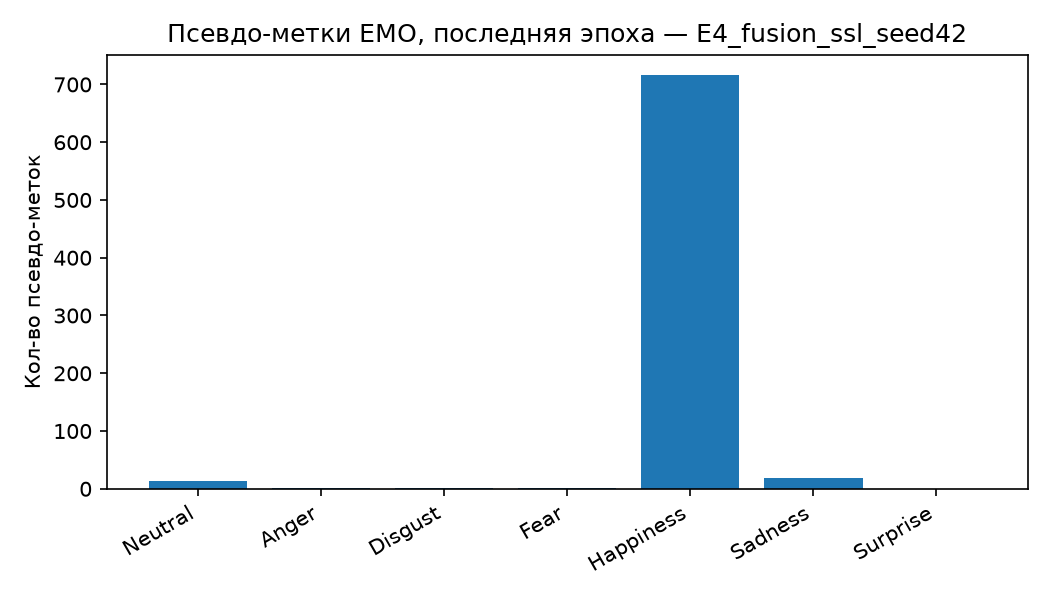

E4_fusion_ssl_emo_w_seed42_pseudo_hist.png


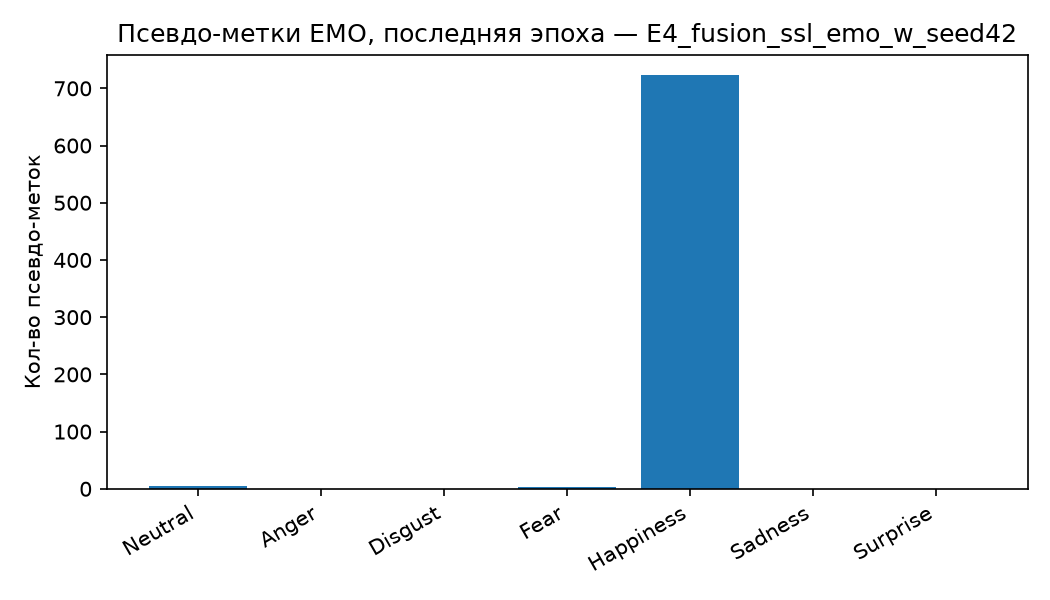

attn_zeros_fusion_gradnorm_seed42_mf1.png


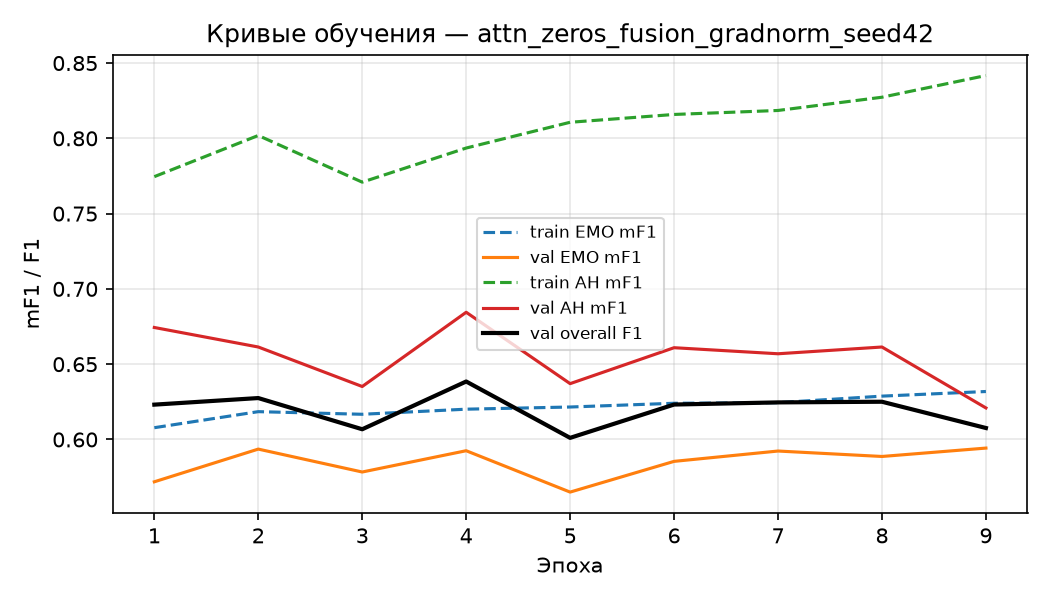

In [9]:
# Покажем пару ключевых графиков прямо в ноутбуке
from IPython.display import Image, display as disp
for key in ["E4_fusion_ssl_seed42_pseudo_hist.png",
            "E4_fusion_ssl_emo_w_seed42_pseudo_hist.png",
            "attn_zeros_fusion_gradnorm_seed42_mf1.png"]:
    p = PLOTS / key
    if p.exists():
        print(key); disp(Image(str(p)))

## 6. Выводы

1. **Fusion vs single (§1):** stage-2 не превосходит одиночные stage-1 энкодеры —
   ER почти не меняется, AHR даже чуть ниже одиночной AH-модели. Cross-attention на
   замороженных фичах вносит шум, а не сигнал.

2. **Веса эмоций (§2):** поднимают `emo_uar`/`emo_mwacc` (recall на редких классах),
   почти не трогая `emo_mf1` — ровно как предсказывал ранний разбор (веса = размен
   precision↔recall, а не реальный прирост разделимости). На `overall_f1` веса
   дают значимый плюс у SSL/unfreeze (E4 +0.015, E6 +0.014; CI без 0), нейтральны у E3/E5.

3. **Attention-ablation (§3):** zeros/mhla/elsa не пробивают потолок softmax ни на
   stage-1, ни в сквозном fusion_grad_norm → потолок — свойство представления
   (bge-small) и задачи, а не механизма внимания. (seed 42; для значимости нужны сиды.)

4. **Общий вывод:** ни fusion, ни веса, ни смена внимания не дают системного прироста.
   Это согласованный негативный результат с понятным механизмом.

> ⚠️ Attention-блок и веса — на малом числе сидов (1 и 5). Для защищаемых выводов
> прогнать на 10 сидах и пройтись `training/significance.py`.